# 03 Train Neural BCJR
## Цель ноутбука
Обучить LLR-calibrated Neural BCJR prototype и сохранить checkpoint.

## Что здесь происходит
Neural-компонент калибрует входные LLR, после чего используется классический BCJR core. Это позволяет проверить, помогает ли learned-калибровка улучшить качество декодирования.

## Что получаем в конце
- checkpoint `best_neural_bcjr.pt`;
- историю функции потерь;
- быструю проверку результата после обучения.

In [1]:
# [1/8] Импорты и поиск корня проекта
from pathlib import Path
import sys
import yaml
import pandas as pd
from IPython.display import display, Image

def find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    while cur != cur.parent:
        if (cur / 'pyproject.toml').exists():
            return cur
        cur = cur.parent
    raise RuntimeError('Repo root not found')

ROOT = find_repo_root(Path.cwd())
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

print('[1/8] Импорты загружены')
print('ROOT =', ROOT)


[1/8] Импорты загружены
ROOT = C:\Users\maks\Desktop\maga\диплом\практика\2\dp-codex-create-repository-for-neural-viterbi-and-bcjr-j6ug56


# Настройка параметров эксперимента


In [2]:
# [2/8] Параметры эксперимента (редактируются в этой ячейке)
PARAMS = {
    'run_name': 'notebook_nb_train',
    'K': 64,
    'num_blocks': 12,
    'snr_db_list': [0, 2],
    'seed': 123,
    'decoders': ['bcjr', 'neural_bcjr'],
    'epochs': 3,
    'learning_rate': 1e-3,
    'hidden_dim': 16,
    'reuse_saved_signals': False,
    'training_enabled': True,
}
print('[2/8] Параметры заданы')
display(pd.Series(PARAMS))


[2/8] Параметры заданы


run_name                 notebook_nb_train
K                                       64
num_blocks                              12
snr_db_list                         [0, 2]
seed                                   123
decoders               [bcjr, neural_bcjr]
epochs                                   3
learning_rate                        0.001
hidden_dim                              16
reuse_saved_signals                  False
training_enabled                      True
dtype: object

In [3]:
# [3/8] Загружаем YAML, меняем параметры и сохраняем notebook-конфиг
from comm_ai.utils.io import load_yaml

cfg = load_yaml(ROOT / 'src/comm_ai/config/experiments/awgn_small.yaml')
cfg['experiment']['run_name'] = PARAMS['run_name']
cfg['experiment']['K'] = PARAMS['K']
cfg['experiment']['num_blocks'] = PARAMS['num_blocks']
cfg['experiment']['snr_db_list'] = PARAMS['snr_db_list']
cfg['experiment']['seed'] = PARAMS['seed']
cfg['experiment']['decoders'] = PARAMS['decoders']
cfg['experiment']['reuse_saved_signals'] = PARAMS['reuse_saved_signals']

# Все результаты ноутбуков сохраняем в корневую папку проекта, а не рядом с ноутбуком
cfg['paths']['outputs_root'] = str(ROOT / 'outputs' / 'runs')

cfg['training']['enabled'] = PARAMS['training_enabled']
cfg['training']['epochs'] = PARAMS['epochs']
cfg['training']['learning_rate'] = PARAMS['learning_rate']
cfg['training']['hidden_dim'] = PARAMS['hidden_dim']

nb_cfg_path = ROOT / 'outputs/runs' / f"{PARAMS['run_name']}_notebook_config.yaml"
nb_cfg_path.parent.mkdir(parents=True, exist_ok=True)
nb_cfg_path.write_text(yaml.safe_dump(cfg, sort_keys=False), encoding='utf-8')
print('[3/8] Конфиг сохранён в', nb_cfg_path)


[3/8] Конфиг сохранён в C:\Users\maks\Desktop\maga\диплом\практика\2\dp-codex-create-repository-for-neural-viterbi-and-bcjr-j6ug56\outputs\runs\notebook_nb_train_notebook_config.yaml


In [4]:
# [5/8] Запуск эксперимента
from comm_ai.experiments.run_experiment import run
out_dir = run(str(nb_cfg_path))
print('[5/8] Эксперимент завершён, артефакты в', out_dir)


train_neural_bcjr: 100%|██████████| 3/3 [00:00<00:00, 410.87it/s]


[5/8] Эксперимент завершён, артефакты в outputs\runs\notebook_nb_train


In [5]:
# [6/8] Обучение Neural BCJR через Python API
from comm_ai.training.train_neural_bcjr import train_from_config as train_nb_from_config

ckpt_path, loss_history = train_nb_from_config(cfg, dataset_path=out_dir / 'signals.npz')
print('[6/8] Обучение завершено')
print('Checkpoint:', ckpt_path)
print('Loss history:', loss_history)


train_neural_bcjr: 100%|██████████| 3/3 [00:00<00:00, 596.49it/s]

[6/8] Обучение завершено
Checkpoint: outputs\runs\notebook_nb_train\checkpoints\best_neural_bcjr.pt
Loss history: [0.32606086134910583, 0.32512596249580383, 0.3242325484752655]


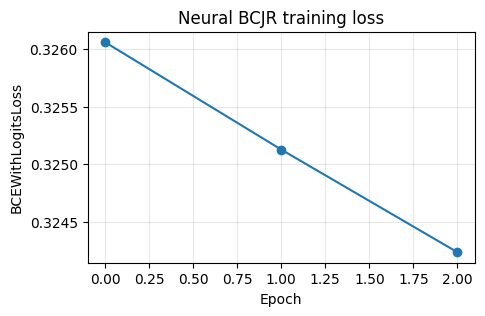

In [6]:
# [7/8] Визуализация loss
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 3))
plt.plot(loss_history, marker='o')
plt.title('Neural BCJR training loss')
plt.xlabel('Epoch')
plt.ylabel('BCEWithLogitsLoss')
plt.grid(alpha=0.3)
plt.show()


In [ ]:
# [8/8] Быстрая проверка после обучения
out_dir = run(str(nb_cfg_path))
results = pd.read_csv(out_dir / 'results.csv')
display(results)


,decoder,snr_db,ber,fer,decode_time_s,complexity_proxy,trained_model_used
0,bcjr,0.0,0.248698,0.833333,0.118228,4096,False
1,bcjr,2.0,0.022135,0.250000,0.120948,4096,False
2,neural_bcjr,0.0,0.266927,0.833333,0.141033,4096,True
3,neural_bcjr,2.0,0.018229,0.250000,0.145478,4096,True


## Итог
Checkpoint сохранен и готов к использованию в основном сравнительном ноутбуке `04_compare_all.ipynb`. График loss помогает понять, стабилизировалось ли обучение.